In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

from sklearn.model_selection import GridSearchCV

In [2]:
from sklearn import datasets 
fetch_california_housing = datasets.fetch_california_housing()
print(fetch_california_housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [3]:
# признаки датасета
fetch_california_housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

    - MedInc        Средний доход в группе кварталов
    - HouseAge      Средний возраст семьи в группе кварталов
    - AveRooms      Среднее количество комнат в семье
    - AveBedrms     Среднее количество спален в семье
    - Population    Численность населения в группе кварталов
    - AveOccup      Среднее количество членов семьи, проживающих в кварталах
    - Latitude      Широта группы кварталов
    - Longitude     Долгота группы кварталов
    
Целевой переменной является средняя стоимость дома для районов Калифорнии, выраженная в сотнях тысяч долларов (100 000 долларов США).

Этот набор данных был получен на основе переписи населения США 1990 года с использованием одной строки для каждой
группы переписных блоков. Многоквартирный дом - это наименьшая географическая единица, для которой в США используются данные переписи населения.

Бюро переписи населения публикует выборочные данные (в многоквартирном доме обычно проживает
от 600 до 3000 человек).

Домохозяйство - это группа людей, проживающих в одном доме. Поскольку среднее
количество комнат и спальных комнат в этом наборе данных указано на домохозяйство, эти
столбцы могут иметь неожиданно большие значения для групп кварталов с небольшим количеством домохозяйств
и большим количеством пустующих домов, таких как курорты для отдыха.

In [4]:
# целевая переменная
fetch_california_housing.target_names

['MedHouseVal']

In [5]:
data_x_1 = pd.DataFrame(fetch_california_housing.data, columns=fetch_california_housing.feature_names)
data_x_1.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [6]:
data_y_1=pd.DataFrame(fetch_california_housing.target, columns=fetch_california_housing.target_names)
data_y_1.head()

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [7]:
# изучение пропусков
data_x_1.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

Пропусков в данных нет.

In [8]:
data_x_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


# 1 Модель регрессии

In [9]:
X_train, X_test, y_train, y_test = train_test_split(data_x_1,data_y_1, test_size = 0.2, random_state=42)

In [10]:
model = LinearRegression()

In [11]:
model.fit(X_train, y_train)

LinearRegression()

In [12]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [13]:
score_test = model.score(X_test, y_test)
score_train = model.score(X_train, y_train)
print(f'score на тестовых данных: {score_test}')
print(f'score на тренировочных данных: {score_train}')

score на тестовых данных: 0.5757877060324511
score на тренировочных данных: 0.6125511913966952


Т.к. модель регрессионная, то функция score является метрикой R² (доля дисперсии в y, объяснённая моделью). И на тренировочных и на тестовых данных модель имеет умеренную объяснительную способность. На тренировочных данных метрика имеет не много лучшее значение.

# 2 Модель - дерево

In [14]:
regressor = DecisionTreeRegressor(max_depth=5, random_state=0)

In [15]:
regressor.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=0)

In [16]:
score_test_tree = regressor.score(X_test, y_test)
score_train_tree = regressor.score(X_train, y_train)
print(f'score на тестовых данных: {score_test_tree}')
print(f'score на тренировочных данных: {score_train_tree}')

score на тестовых данных: 0.5997321244428706
score на тренировочных данных: 0.6376786573648903


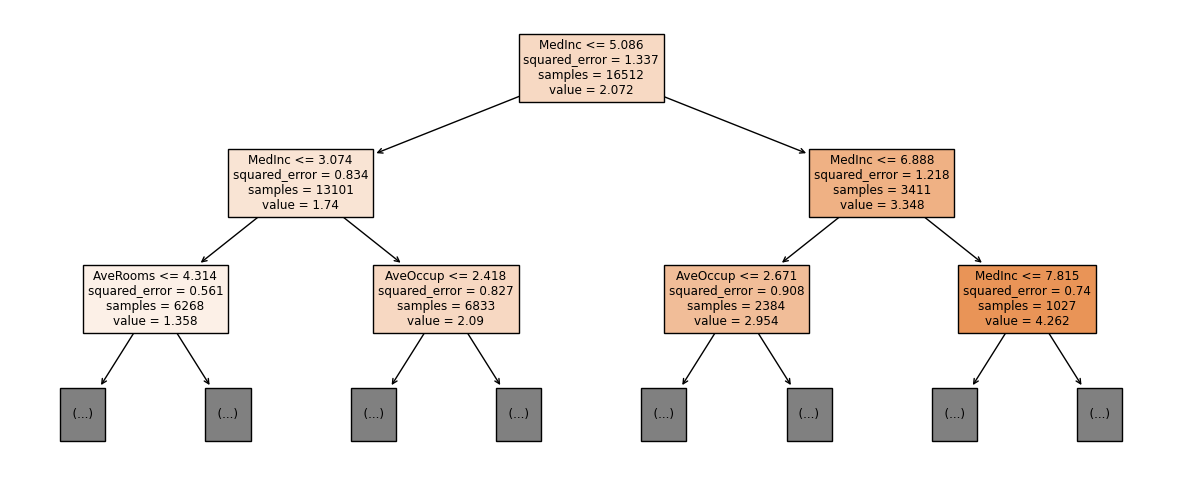

In [17]:
plt.figure(figsize=(15, 6))
plot_tree(regressor, feature_names=X_train.columns, filled=True, max_depth=2);

In [18]:
# подберем оптимальную глубину дерева
param_grid = {
    'max_depth': range(1,16,1)
}

regressor = DecisionTreeRegressor(random_state=0)
grid_search = GridSearchCV(regressor, param_grid, cv=5, scoring = 'r2')
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_score = grid_search.best_score_

In [19]:
print("Лучшее значение гиперпараметра:", grid_search.best_params_)
print("Лучшее значение метрики при кросс-валидации:", grid_search.best_score_)

Лучшее значение гиперпараметра: {'max_depth': 9}
Лучшее значение метрики при кросс-валидации: 0.7007226717790909


In [20]:
regressor_9 = DecisionTreeRegressor(max_depth=9, random_state=0)

In [21]:
regressor_9.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=9, random_state=0)

In [22]:
score_test_tree_9 = regressor_9.score(X_test, y_test)
score_train_tree_9 = regressor_9.score(X_train, y_train)
print(f'score на тестовых данных: {score_test_tree_9}')
print(f'score на тренировочных данных: {score_train_tree_9}')

score на тестовых данных: 0.6850835020193997
score на тренировочных данных: 0.7999255297501255


# Вывод

Модель линейной регрессии показала хуже качество как на тестовых, так и на тренировочных данных, чем дерево решений.

При использовании GridSearchCV с учетом кроссвалидации удалось определить оптимальную глубину дерева - 9.
С данными параметрами модель имеет наибольшее значение метрики r2. Модель имеет довольно высокую предсказательную способность, при этом модель не переобучилась.

Плюсом использования модели дерева решений является её легкая интерпретируемость - легко визуализировать почему объёкт имеет конкретное значение.
Также она не требует масштабирования признаков, можно применять на ненормализованных признаках.